In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
## GENERATE THE DATASET

# import numpy as np
# import pandas as pd

# # Set random seed for reproducibility
# np.random.seed(42)

# # Generate normal data (benign cases)
# tumor_size = np.random.normal(loc=5, scale=1.5, size=1400)  # Mean 5cm, Std 1.5cm
# cell_density = np.random.normal(loc=50, scale=10, size=1400)  # Mean 50, Std 10

# # Generate anomalous data (malignant cases)
# tumor_size_anomaly = np.random.normal(loc=10, scale=2, size=100)  # Larger tumors
# cell_density_anomaly = np.random.normal(loc=80, scale=15, size=100)  # Higher density

# # Combine normal and anomalous data
# tumor_size = np.concatenate([tumor_size, tumor_size_anomaly])
# cell_density = np.concatenate([cell_density, cell_density_anomaly])

# # Create labels (0 = benign, 1 = malignant)
# labels = np.concatenate([np.zeros(1400), np.ones(100)])

# # Create DataFrame
# df = pd.DataFrame({'Tumor Size': tumor_size, 'Cell Density': cell_density, 'Anomaly': labels})

# # Save dataset
# df.to_csv("cancer_anomaly_dataset.csv", index=False)

# print("Dataset created successfully!")

In [3]:
data = pd.read_csv('cancer_anomaly_dataset.csv')
data.head()

,Tumor Size,Cell Density,Anomaly
0,5.745071,39.530890,0.0
1,4.792604,55.366528,0.0
2,5.971533,61.857042,0.0
3,7.284545,57.189533,0.0
4,4.648770,59.960477,0.0


In [4]:
data.shape

(1500, 3)

## For Unsupervised ML we are just interested in input parameters.

In [5]:
## define input features as 2D matrix
X = data[['Tumor Size', 'Cell Density']]

In [6]:
X.head()

,Tumor Size,Cell Density
0,5.745071,39.530890
1,4.792604,55.366528
2,5.971533,61.857042
3,7.284545,57.189533
4,4.648770,59.960477


In [7]:
## Standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [8]:
pd.DataFrame(X_scaled).head()

,0,1
0,0.188786,-1.015153
1,-0.296214,0.236876
2,0.304101,0.750041
3,0.972691,0.381010
4,-0.369454,0.600091


Text(0, 0.5, 'Cell Density')

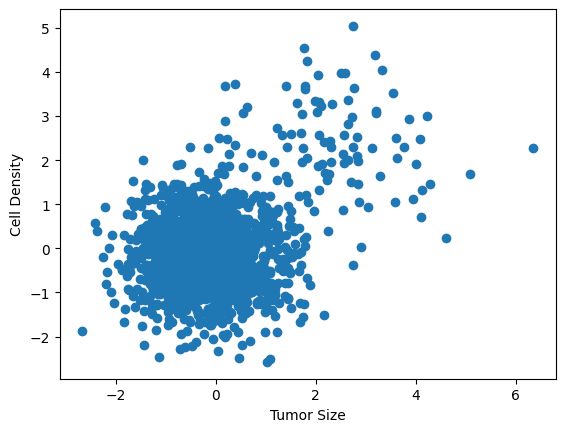

In [9]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1])
plt.xlabel("Tumor Size")
plt.ylabel("Cell Density")

# Grouped points are for normal people. Outliers are detected for cancer patients.

In [10]:
from sklearn.ensemble import IsolationForest

In [11]:
clf = IsolationForest(
  contamination = 0.05
)

clf.fit(X_scaled)

predictions = clf.predict(X_scaled)

In [12]:
predictions

array([ 1,  1,  1, ..., -1, -1,  1])

In [13]:
pd.DataFrame(predictions).value_counts()

 1    1425
-1      75
Name: count, dtype: int64

# Wherever: 1 = Normal data points,   -1 = Outliers

In [14]:
import numpy as np

abn_ind = np.where(predictions < 0)
abn_ind

(array([ 139,  191,  209,  262,  350,  478,  526,  571,  624,  635,  977,
        1151, 1156, 1160, 1401, 1403, 1405, 1408, 1409, 1412, 1413, 1414,
        1415, 1416, 1417, 1418, 1419, 1421, 1425, 1426, 1428, 1429, 1430,
        1432, 1433, 1434, 1435, 1436, 1437, 1438, 1440, 1442, 1444, 1450,
        1451, 1452, 1453, 1454, 1455, 1456, 1458, 1461, 1463, 1464, 1468,
        1469, 1471, 1473, 1474, 1476, 1478, 1480, 1481, 1482, 1483, 1487,
        1489, 1490, 1491, 1492, 1494, 1495, 1496, 1497, 1498], dtype=int64),)

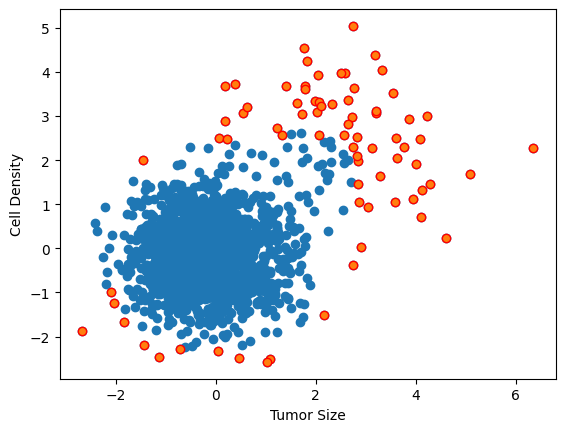

In [15]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1])
plt.xlabel("Tumor Size")
plt.ylabel("Cell Density")

plt.scatter(X_scaled[abn_ind, 0], X_scaled[abn_ind, 1], edgecolors = "r")